In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

#CDMS = os.environ["CDMS"] # set in .bash_profile
#stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
#plt.style.use(stylesheet)

#sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
#import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [4]:
DMCfiles = np.sort(glob.glob('/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Kshell_pos50V_100kEvents_V05-09/DMCOutput/R?/Ge71_Kshell_????????_000???.root'))

In [5]:
# Sort by the last 3 characters
DMCfiles = sorted(DMCfiles, key=lambda s: float(s[-8:-5]))

In [6]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
EventNum = g4dmcHits.AsNumpy(['EventNum'])['EventNum']
X = g4dmcHits.AsNumpy(['X'])['X']*1e3
Y = g4dmcHits.AsNumpy(['Y'])['Y']*1e3
Z = g4dmcHits.AsNumpy(['Z'])['Z']*1e3

R = np.sqrt(X**2 + Y**2)

In [7]:
g4dmcEvent = CDataFrame('G4SimDir/g4dmcEvent', DMCfiles)
EventNum = g4dmcEvent.AsNumpy(['EventNum'])['EventNum']
PhononE = np.sum(g4dmcEvent.AsNumpy(['PhononE'])['PhononE']*1e-3, axis = 1)

In [8]:
RQfiles = np.sort(glob.glob("/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Kshell_pos50V_100kEvents_V05-09/Processed/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"))
#RQfiles_3kHz = np.sort(glob.glob("/scratch/perry/processing/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"))

In [9]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), RQfiles, friends = [[x+":rqDir/eventTree" for x in RQfiles]])

In [10]:
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(0), "PTOFamps>0"])

In [11]:
#RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime", "PTOFchisqLF"])
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = ["SeriesNumber", "EventNumber", "PTOFamps", "PTOFchisqLF"] + [chan + "OFamps" for chan in channels] + [chan + "OFchisqLF" for chan in channels]
df_rqs = df_filtered.AsNumpy(RQs + ['EventTriggerID'])

In [13]:
df = CDataFrame("rqDir/zip"+str(det), RQfiles, friends = [[x+":rqDir/eventTree" for x in RQfiles]])
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(0), "PTOFamps>0"])
df_rqs_3kHz = df_filtered.AsNumpy(RQs + ['EventTriggerID'])

In [14]:
def linearize(x):
    return 1/b * (np.exp(x / a) - 1)

def pt2keV(x):
    lin_pt = linearize(x)
    recoilE = lin_pt * calibFac / LukeFac
    return recoilE

In [15]:
a, b = 2.08e-04, 1.63e+01
calibFac = 21000
LukeFac = 1 + 50 / 3
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps']*10/4)

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


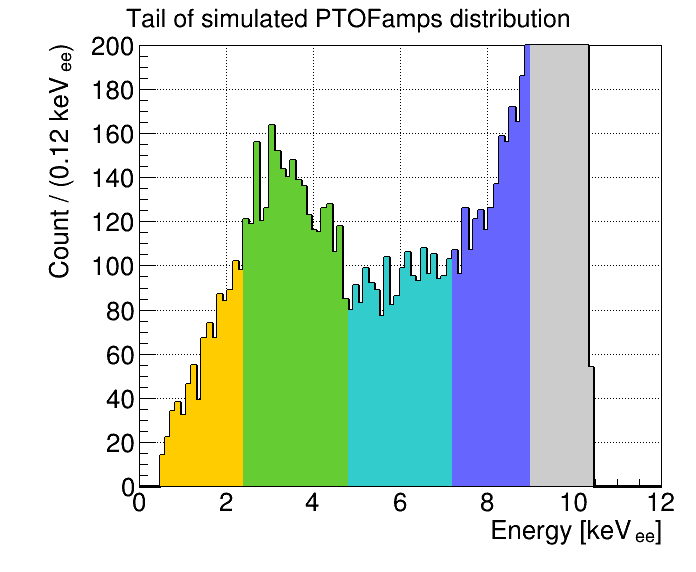

In [16]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)
bins = np.linspace(bins_start, bins_end, nbins + 1)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h", "Tail of simulated PTOFamps distribution;Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]" + ";Count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data1 = df_rqs['PTOFamps_keVee']

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlack)
    
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.SetMaximum(200)
h1.Draw()

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data2 = df_rqs['PTOFamps_keVee'][df_rqs['PTOFamps_keVee'] < bins[20]]

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(0)
h2.SetFillColor(ROOT.kOrange)
h2.SetFillStyle(1001)
h2.Draw("SAME")

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h3 = ROOT.TH1F("h", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data3 = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= bins[20]) & (df_rqs['PTOFamps_keVee'] < bins[40])]

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(0)
h3.SetFillColor(ROOT.kSpring-5)
h3.SetFillStyle(1001)
h3.Draw("SAME")

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h4 = ROOT.TH1F("h", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data4 = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= bins[40]) & (df_rqs['PTOFamps_keVee'] < bins[60])]

for value in data4:
    h4.Fill(value)
h4.SetLineWidth(0)
h4.SetFillColor(ROOT.kCyan-3)
h4.SetFillStyle(1001)
h4.Draw("SAME")

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h5 = ROOT.TH1F("h", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data5 = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= bins[60]) & (df_rqs['PTOFamps_keVee'] < bins[75])]

for value in data5:
    h5.Fill(value)
h5.SetLineWidth(0)
h5.SetFillColor(ROOT.kBlue-7)
h5.SetFillStyle(1001)
h5.Draw("SAME")

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h6 = ROOT.TH1F("h", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data6 = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= bins[75])]

for value in data6:
    h6.Fill(value)
h6.SetLineWidth(0)
h6.SetFillColor(ROOT.kGray)
h6.SetFillStyle(1001)
h6.Draw("SAME")

c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.Update()
c.SetGrid(1,1)
#c.SetLogy()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


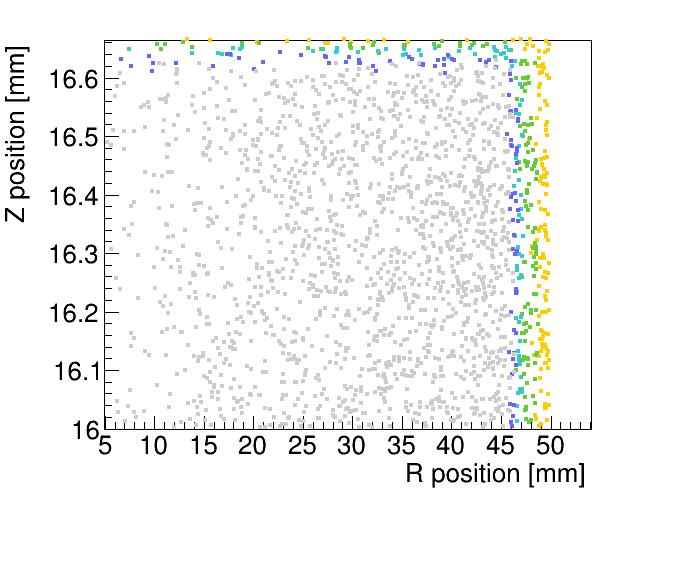

In [20]:
cut = df_rqs['PTOFamps_keVee'] < bins[20]
g1 = ROOT.TGraph(len(R[cut]), R[cut], Z[cut])
g1.SetMarkerStyle(21)
g1.SetMarkerSize(0.6)
g1.SetMarkerColor(ROOT.kOrange)
g1.SetFillColor(ROOT.kOrange)
#g1.GetXaxis().SetRangeUser(40, 50)
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
#g1.SetMinimum(-33.33/2)
#g1.SetMaximum(33.33/2)
g1.SetMinimum(16)
g1.SetMaximum(33.33/2)

# Second dataset
cut = (df_rqs['PTOFamps_keVee'] >= bins[20]) & (df_rqs['PTOFamps_keVee'] < bins[40])
g2 = ROOT.TGraph(len(R[cut]), R[cut], Z[cut])
g2.SetMarkerStyle(21)
g2.SetMarkerSize(0.6)
g2.SetMarkerColor(ROOT.kSpring-5)
g2.SetFillColor(ROOT.kSpring-5)

cut = (df_rqs['PTOFamps_keVee'] >= bins[40]) & (df_rqs['PTOFamps_keVee'] < bins[60])
g3 = ROOT.TGraph(len(R[cut]), R[cut], Z[cut])
g3.SetMarkerStyle(21)
g3.SetMarkerSize(0.6)
g3.SetMarkerColor(ROOT.kCyan-3)
g3.SetFillColor(ROOT.kCyan-3)

cut = (df_rqs['PTOFamps_keVee'] >= bins[60]) & (df_rqs['PTOFamps_keVee'] < bins[75])
g4 = ROOT.TGraph(len(R[cut]), R[cut], Z[cut])
g4.SetMarkerStyle(21)
g4.SetMarkerSize(0.6)
g4.SetMarkerColor(ROOT.kBlue-7)
g4.SetFillColor(ROOT.kBlue-7)

cut = (df_rqs['PTOFamps_keVee'] >= bins[75])
g5 = ROOT.TGraph(len(R[cut]), R[cut], Z[cut])
g5.SetMarkerStyle(21)
g5.SetMarkerSize(0.6)
g5.SetMarkerColor(ROOT.kGray)
g5.SetFillColor(ROOT.kGray)

# Create canvas
#c = ROOT.TCanvas("c", "Canvas", int(500*2), int(300*2))
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.25)
c.SetRightMargin(0.15)
c.SetTopMargin(0.07)

# Draw first graph
g1.SetTitle(" ;R position [mm];Z position [mm]")
g1.Draw("AP")  # A = axis, P = points

# Draw second graph on same canvas
g2.Draw("P SAME")  # P = points, SAME = overlay
g3.Draw("P SAME")  # P = points, SAME = overlay
g4.Draw("P SAME")  # P = points, SAME = overlay
g5.Draw("P SAME")  # P = points, SAME = overlay

c.Draw()

In [16]:
K_DMC_cut = (df_rqs['PTOFamps_keVee'] > 9.7) & (df_rqs['PTOFamps_keVee'] < 11.5)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


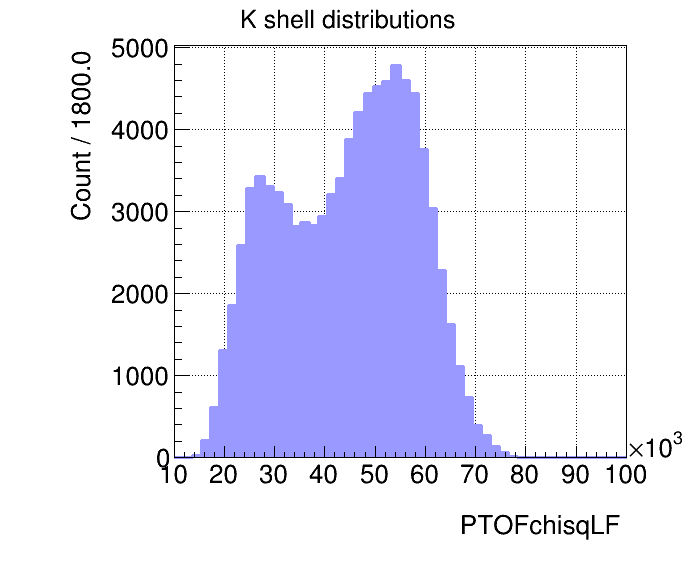

In [17]:
ROOT.gStyle.SetOptStat(0)
bins_start = 10e3
bins_end = 1e5
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", "K shell distributions;PTOFchisqLF" + ";Count / " + str(bindiff) + "", nbins, bins_start, bins_end)
data1 = df_rqs['PTOFchisqLF'][K_DMC_cut]

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-9)
h1.SetFillColor(ROOT.kBlue-9)
h1.SetFillStyle(1001)
#h1.SetMaximum(850)
    
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

c.SetLeftMargin(0.25)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.1)
c.SetTopMargin(0.08)
h1.Draw()
c.SetGrid(1,1)
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


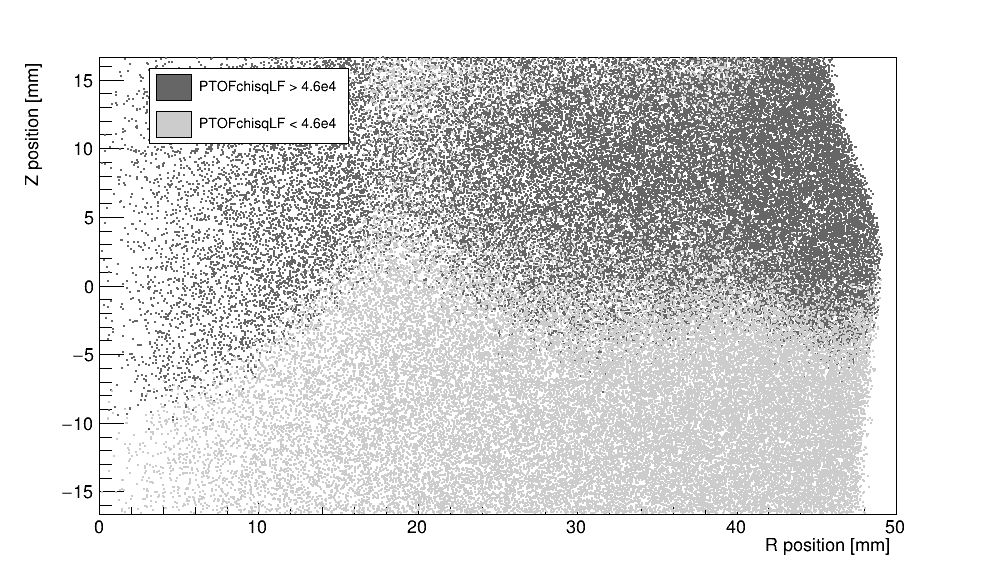

In [18]:
g1 = ROOT.TGraph(len(R[K_DMC_cut & (df_rqs['PTOFchisqLF'] > 46000)]), R[K_DMC_cut & (df_rqs['PTOFchisqLF'] > 46000)], Z[K_DMC_cut & (df_rqs['PTOFchisqLF'] > 46000)])
g1.SetMarkerStyle(21)
g1.SetMarkerSize(0.25)
g1.SetMarkerColor(ROOT.kGray+2)
g1.SetFillColor(ROOT.kGray+2)
g1.GetXaxis().SetRangeUser(0, 50)
g1.SetMinimum(-33.33/2)
g1.SetMaximum(33.33/2)

# Second dataset
g2 = ROOT.TGraph(len(R[K_DMC_cut & (df_rqs['PTOFchisqLF'] < 46000)]), R[K_DMC_cut & (df_rqs['PTOFchisqLF'] < 46000)], Z[K_DMC_cut & (df_rqs['PTOFchisqLF'] < 46000)])
g2.SetMarkerStyle(21)
g2.SetMarkerSize(0.25)
g2.SetMarkerColor(ROOT.kGray)
g2.SetFillColor(ROOT.kGray)

# Create canvas
c = ROOT.TCanvas("c", "Canvas", 1000, 600)

# Draw first graph
g1.SetTitle(" ;R position [mm];Z position [mm]")
g1.Draw("AP")  # A = axis, P = points

# Draw second graph on same canvas
g2.Draw("P SAME")  # P = points, SAME = overlay

# Optional: Add legend
legend = ROOT.TLegend(0.15, 0.75, 0.35, 0.88)
legend.AddEntry(g1, "PTOFchisqLF > 4.6e4", "f")
legend.AddEntry(g2, "PTOFchisqLF < 4.6e4", "f")
legend.Draw()

c.Draw()

Warning in <TROOT::Append>: Replacing existing TGraph2D: Graph2D (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


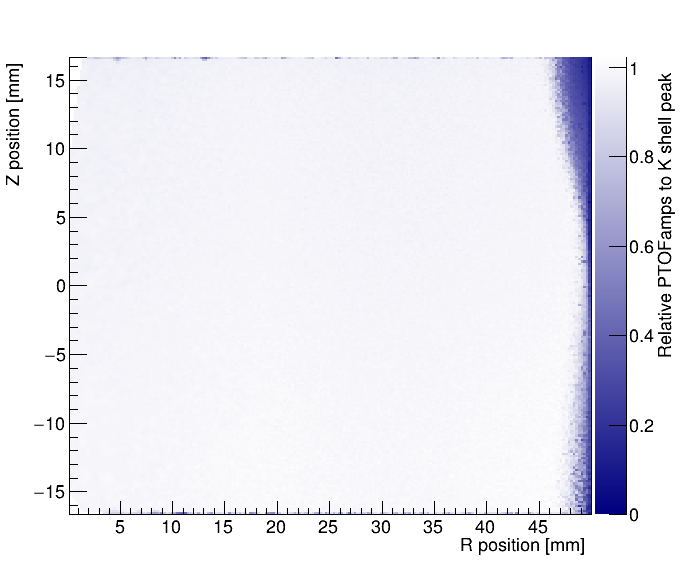

In [24]:
# Create the TGraph2D
g2d = ROOT.TGraph2D(int(len(R)), R, Z, df_rqs['PTOFamps_keVee'] / 10.085)
g2d.SetTitle(" ;R position [mm];Z position [mm];Relative PTOFamps to K shell peak")

# Create custom color palette (white to dark blue)
red   = np.array([0.0, 1.0])
green = np.array([0.0, 1.0])
blue  = np.array([0.5, 1.0])
stops = np.array([0.0, 1.0])
npoints = 2
ncolors = 255
ROOT.TColor.CreateGradientColorTable(npoints, stops, red, green, blue, ncolors)
ROOT.gStyle.SetNumberContours(ncolors)

# Draw the heatmap
c = ROOT.TCanvas("c", "Heatmap from Arrays", 700, 600)
ROOT.gStyle.SetOptStat(0)
g2d.SetNpx(200)  # Number of bins along X (default is 40)
g2d.SetNpy(200)  # Number of bins along Y
g2d.GetXaxis().SetLabelSize(0.05)
g2d.GetYaxis().SetLabelSize(0.05)
g2d.GetXaxis().SetTitleSize(0.5)
g2d.GetYaxis().SetTitleSize(0.5)

#h = g2d.GetHistogram()
#h.SetMinimum(0)    # lower bound for Z scale
#h.SetMaximum(1.05)   # upper bound for Z scale

g2d.Draw("COLZ")  # "COLZ" shows color and color bar

#c.SetLeftMargin(0.15)
#c.SetBottomMargin(0.15)
c.SetRightMargin(0.15)
#c.SetTopMargin(0.08)
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


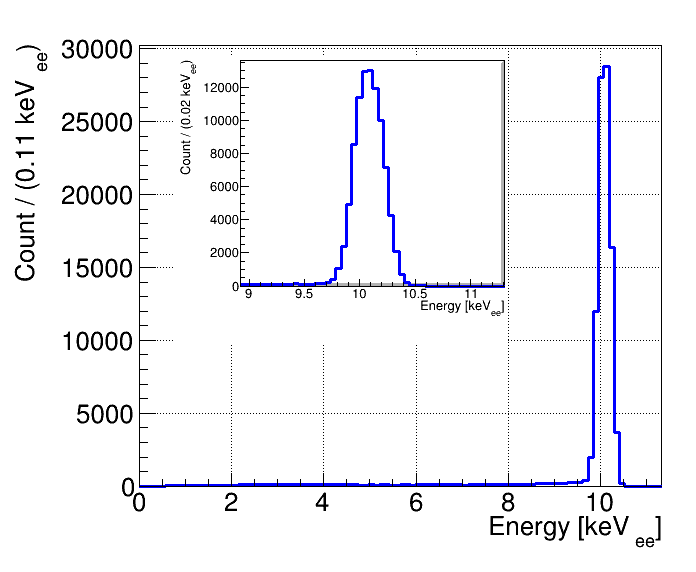

In [22]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = pt2keV(30e-6)
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data1 = np.array(df_rqs['PTOFamps_keVee'], dtype='float64')

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
#h1.GetXaxis().SetRangeUser(-4, 12)
h1.Draw()

# Create the inset histogram (for example, zoomed-in portion)
inset_hist = ROOT.TH1F("inset_hist", ";Energy [keV_{ee}]" + ";Count / (0.02 keV_{ee})", 50, pt2keV(24e-6), pt2keV(30e-6))
for value in data1:
    inset_hist.Fill(value)
inset_hist.SetLineWidth(3)
# Create a small inset pad (TPad)
# Define the position and size of the inset as (x1, y1, x2, y2), where values are between 0 and 1
inset_pad = ROOT.TPad("inset_pad", "Inset Pad", 0.25, 0.4, 0.73, 0.90)
#inset_pad.SetBorderSize(2)  # Optional: Set the border size of the inset
inset_pad.SetFillColor(0)   # Set background color of inset (0 means transparent)
inset_pad.Draw()  # Draw the inset pad on the main canvas
inset_pad.cd()  # Switch to the inset pad

# Draw the inset histogram (zoomed-in version)
inset_hist.SetLineColor(ROOT.kBlue)
inset_hist.GetXaxis().SetLabelSize(0.05)
inset_hist.GetYaxis().SetLabelSize(0.05)
inset_hist.GetXaxis().SetTitleSize(0.05)
inset_hist.GetYaxis().SetTitleSize(0.05)
inset_hist.Draw()

# Optionally, add a box around the inset plot to highlight it
inset_pad.SetFrameBorderSize(3)
inset_pad.SetFrameBorderMode(1)
# Adjust the margins of the inset pad
inset_pad.SetLeftMargin(0.2)    # Reduce left margin
inset_pad.SetRightMargin(0.01)   # Reduce right margin
inset_pad.SetTopMargin(0.01)     # Reduce top margin
inset_pad.SetBottomMargin(0.2)  # Reduce bottom margin

# Draw a border around the inset axis (optional)
#inset_pad.SetFrameFillColor(ROOT.kWhite)  # Set background of inset border
#inset_pad.SetFrameLineColor(ROOT.kBlack)


c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.Update()
c.SetGrid(1,1)
c.Draw()

In [23]:
K_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= pt2keV(20e-6)) & (df_rqs['PTOFamps_keVee'] <= pt2keV(34e-6))]

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.00363e+01  4.78118e-02    9.70987e+00  1.01880e+01
     2 #sigma1      1.05256e-01  3.16377e-02    3.50686e-02  3.51446e-01
     3 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     4 c1           7.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     5 m0           1.00363e+01  7.58513e-02    9.31354e+00  1.01880e+01
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        2500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=-13720.4

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


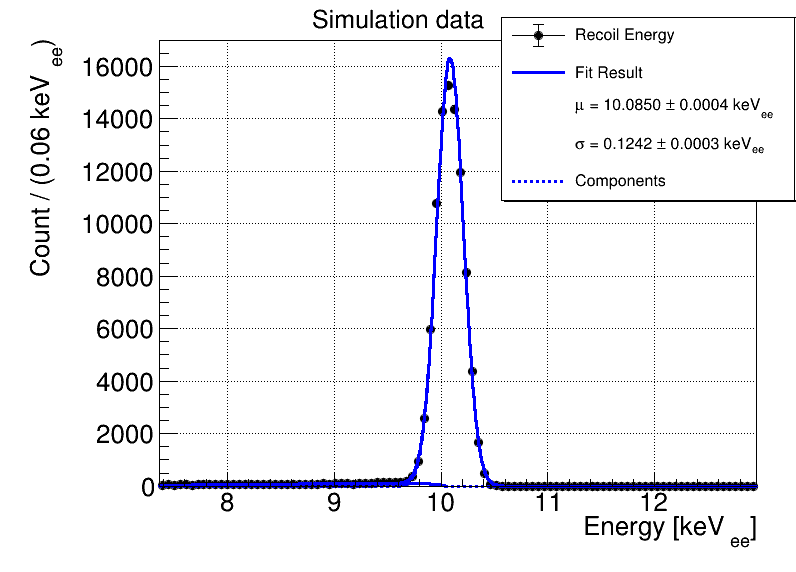

In [24]:
ROOT.gStyle.SetOptStat(0)
bins_start = pt2keV(20e-6)
bins_end = pt2keV(34e-6)
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", f";Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", pt2keV(26.82e-6), pt2keV(26e-6), pt2keV(27.2e-6))
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", pt2keV(0.3e-6), pt2keV(0.1e-6), pt2keV(1e-6))

# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", pt2keV(26.82e-6), pt2keV(25e-6), pt2keV(27.2e-6))  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

g1 = ROOT.RooGaussian("g1", "#g1", x, mean_1, sigma_1)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.7, 0.0, 1.0)

# Convert numpy array into RooFit object
model = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, argus), ROOT.RooArgList(frac1))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("Simulation data"))
frame.SetLabelSize(0.05)
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle("Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name(f"Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("g1"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

#upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
#lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
#mean_upper_bound = upper_bound.getVal()
#mean_lower_bound = lower_bound.getVal()
#x.setRange("gaussRange", bins_start, mean_upper_bound)

#frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
#data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
#model.plotOn(frame_narrow,
#             ROOT.RooFit.Range("gaussRange"),
#             ROOT.RooFit.Name("model_narrow"))
#chi2_narrow = frame_narrow.chiSquare(5)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu = " + f"{mean_1.getVal():.4f} #pm {mean_1.getPropagatedError(fit_result):.4f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma = " + f"{sigma_1.getVal():.4f} #pm {sigma_1.getPropagatedError(fit_result):.4f}" + " keV_{ee}", "")
#legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

#frame.SetMinimum(14000)
frame.SetMaximum(17000)  # Adjust based on your data
#frame.SetMaximum(1980)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.07)
frame.Draw()
legend.Draw()
c.SetGrid(1,1)
c.Draw()

In [25]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))

mean_upper_bound = upper_bound.getVal()
err_upper_bound = upper_bound.getPropagatedError(fit_result)
mean_lower_bound = lower_bound.getVal()
err_lower_bound = lower_bound.getPropagatedError(fit_result)

print('The range of the peak is ' + str_with_err(mean_lower_bound, err_lower_bound) + ' keV to ' + str_with_err(mean_upper_bound, err_upper_bound) + ' keV')

rangeCut = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound)
rangeCut_max = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound - err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound + err_upper_bound)
rangeCut_min = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound + err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound - err_upper_bound)

count = sum(rangeCut)
count_stat = np.sqrt(count)
count_variation = np.mean([abs(count - sum(rangeCut_min)), abs(count - sum(rangeCut_max))])
count_err = np.sqrt( count_stat**2 + count_variation**2 )

print('The number of events inside the peak range is ' + str(round(count, 2)) + ' +/- ' + str(round(count_err, 2)))

The range of the peak is 9.712(1) keV to 10.4576(10) keV
The number of events inside the peak range is 91084 +/- 301.89


In [29]:
nevent_window = sum((df_rqs['PTOFamps_keVee'] >= bins_start) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound))

# signal events in peak
print('The fraction of signal events in the peak is ' + str(round(count / nevent_window * 100, 2)) + ' +/- ' + str(round(count_err / nevent_window * 100, 3)))

# signal events below peak
signal_tail = nevent_window - count
signal_tail_err = count_err
print('The fraction of signal events in the tail is ' + str(round(signal_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(signal_tail_err / nevent_window * 100, 2)))

# non-peak signal to peak signal
ratio = signal_tail / count
ratio_err = np.sqrt( (signal_tail_err / count)**2 + (signal_tail / count**2 * count_err)**2)
print('The ratio of non-peak signal to peak signal is ' + str(round(ratio, 3)) + ' +/- ' + str(round(ratio_err, 3)))

The fraction of signal events in the peak is 96.4 +/- 0.32
The fraction of signal events in the tail is 3.6 +/- 0.32
The ratio of non-peak signal to peak signal is 0.037 +/- 0.003


In [30]:
RQfiles = np.sort(glob.glob("/scratch/group/mitchcomp/CDMS/data/perry5334/Ge71_Lshell_50V_tuned_noise/Processed_triangle/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"))

In [31]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), RQfiles, friends = [[x+":rqDir/eventTree" for x in RQfiles]])

In [32]:
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(0), "PTOFamps>0"])

In [33]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = ["SeriesNumber", "EventNumber", "PTOFamps", "PTOFchisqLF"] + [chan + "OFamps" for chan in channels] + [chan + "OFchisqLF" for chan in channels]
df_rqs = df_filtered.AsNumpy(RQs + ['EventTriggerID'])

In [34]:
a, b = 2.08e-04, 1.63e+01
calibFac = 21000
LukeFac = 1 + 50 / 3
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps']*10/4)

In [35]:
L_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= 0.85) & (df_rqs['PTOFamps_keVee'] <= 1.7)]

 **********
 **   13 **SET PRINT           1
 **********
 **********
 **   14 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.25000e+00  5.00000e-02    1.00000e+00  1.50000e+00
     2 #sigma1      1.00000e-01  4.95000e-02    1.00000e-03  1.00000e+00
     3 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     4 c1           7.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     5 m0           1.20000e+00  1.50000e-02    1.10000e+00  1.25000e+00
 **********
 **   15 **SET ERR         0.5
 **********
 **********
 **   16 **SET PRINT           1
 **********
 **********
 **   17 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **   18 **MIGRAD        2500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=-17672.2

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


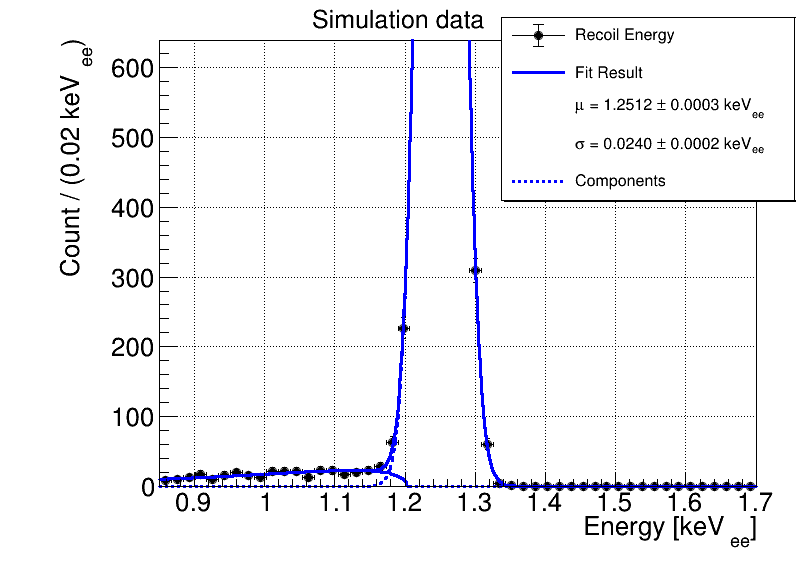

In [39]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0.85
bins_end = 1.7
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", f";Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 1.25, 1, 1.5)
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", 0.1, 0.001, 1)

# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", 1.2, 1.1, 1.25)  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

g1 = ROOT.RooGaussian("g1", "#g1", x, mean_1, sigma_1)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.7, 0.0, 1.0)

# Convert numpy array into RooFit object
model = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, argus), ROOT.RooArgList(frac1))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("Simulation data"))
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle("Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name(f"Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("g1"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

#upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
#lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
#mean_upper_bound = upper_bound.getVal()
#mean_lower_bound = lower_bound.getVal()
#x.setRange("gaussRange", bins_start, mean_upper_bound)

#frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
#data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
#model.plotOn(frame_narrow,
#             ROOT.RooFit.Range("gaussRange"),
#             ROOT.RooFit.Name("model_narrow"))
#nbins = np.round(mean_upper_bound - mean_lower_bound) / bindiff
#chi2_narrow = frame_narrow.chiSquare(5)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu = " + f"{mean_1.getVal():.4f} #pm {mean_1.getPropagatedError(fit_result):.4f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma = " + f"{sigma_1.getVal():.4f} #pm {sigma_1.getPropagatedError(fit_result):.4f}" + " keV_{ee}", "")
#legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

#frame.SetMinimum(0)
#frame.SetMaximum(3000)  # Adjust based on your data
frame.SetMaximum(640)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.07)
frame.Draw()
legend.Draw()
c.SetGrid(1,1)
c.Draw()

In [40]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))

mean_upper_bound = upper_bound.getVal()
err_upper_bound = upper_bound.getPropagatedError(fit_result)
mean_lower_bound = lower_bound.getVal()
err_lower_bound = lower_bound.getPropagatedError(fit_result)

print('The range of the peak is ' + str_with_err(mean_lower_bound, err_lower_bound) + ' keV to ' + str_with_err(mean_upper_bound, err_upper_bound) + ' keV')

rangeCut = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound)
rangeCut_max = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound - err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound + err_upper_bound)
rangeCut_min = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound + err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound - err_upper_bound)

count = sum(rangeCut)
count_stat = np.sqrt(count)
count_variation = np.mean([abs(count - sum(rangeCut_min)), abs(count - sum(rangeCut_max))])
count_err = np.sqrt( count_stat**2 + count_variation**2 )

print('The number of events inside the peak range is ' + str(round(count, 2)) + ' +/- ' + str(round(count_err, 2)))

The range of the peak is 1.1793(6) keV to 1.3230(6) keV
The number of events inside the peak range is 9150 +/- 95.76


In [41]:
nevent_window = sum((df_rqs['PTOFamps_keVee'] >= bins_start) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound))

# signal events in peak
print('The fraction of signal events in the peak is ' + str(round(count / nevent_window * 100, 2)) + ' +/- ' + str(round(count_err / nevent_window * 100, 3)))

# signal events below peak
signal_tail = nevent_window - count
signal_tail_err = count_err
print('The fraction of signal events in the tail is ' + str(round(signal_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(signal_tail_err / nevent_window * 100, 2)))

# non-peak signal to peak signal
ratio = signal_tail / count
ratio_err = np.sqrt( (signal_tail_err / count)**2 + (signal_tail / count**2 * count_err)**2)
print('The ratio of non-peak signal to peak signal is ' + str(round(ratio, 3)) + ' +/- ' + str(round(ratio_err, 3)))

The fraction of signal events in the peak is 96.37 +/- 1.009
The fraction of signal events in the tail is 3.63 +/- 1.01
The ratio of non-peak signal to peak signal is 0.038 +/- 0.01


In [45]:
ufloat(0.024, 0.015) / ufloat(0.037, 0.003)

0.6486486486486487+/-0.4088026179485583